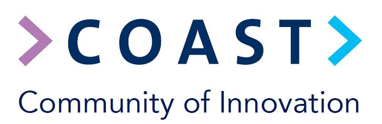

# A beginner's walk-through: predicting chemical biodegradability with scikit-learn

This notebook is a **teaching version** of a real research workflow. It is based on, and
uses the actual curated data from:

> **Körner, P.; Glüge, J.; Glüge, S.; Scheringer, M.** *Critical insights into data curation
> and label noise for accurate prediction of aerobic biodegradability of organic chemicals.*
> **Environ. Sci.: Processes Impacts**, 2024, 26, 1780–1795.
> DOI: [10.1039/D4EM00431K](https://doi.org/10.1039/D4EM00431K)
> Code & data: <https://github.com/pkoerner6/Prediction-of-Aerobic-Biodegradability-of-Organic-Chemicals>

**What the paper is about (in one paragraph):** a chemical is called *readily
biodegradable* (RB) if it passes a standardised lab test showing that microorganisms can
break it down; otherwise it is *not readily biodegradable* (NRB). Running the lab test for
every chemical on the market is slow and expensive, so researchers try to **predict**
RB/NRB directly from a chemical's structure using Machine Learning (ML). The authors show
that a lot of the difficulty in this task actually comes from **noisy/uncertain labels**
in the training data, not from the ML algorithm itself. After carefully cleaning the
dataset (their `Curated_Final` dataset), a gradient-boosted tree model (XGBoost) trained
on **MACCS structural keys** reached a balanced accuracy of about **94%** — the best result
reported so far for this task (see Table 1 and Fig. 3 of the paper).

**What this notebook does:** it reproduces a simplified version of that final modelling
step (Sections 3.4–3.7 of the paper) using only `numpy`, `pandas`, `scikit-learn`, and
`RDKit` (for turning molecules into numbers). The goal is **not** to reproduce every
detail of the paper, but to walk a beginner through the *generic recipe* that almost every
scikit-learn classification project follows:

1. Load the data.
2. Turn the raw input (here: chemical structures) into numeric **features**.
3. Split/resample the data correctly, respecting class imbalance.
4. Choose one or several candidate models.
5. Evaluate them fairly with cross-validation and an appropriate metric.
6. Compare and visualise the results.

Every code cell below has line-by-line comments explaining *what* each instruction does
and, just as importantly, *why* it is there. Cells that install packages or require
internet access are clearly marked.


## 0. Setup: installing and importing the tools we need

We use four libraries:

| Library | What it's for here |
|---|---|
| `pandas` | loading and manipulating the tabular dataset (rows = chemicals, columns = properties) |
| `numpy` | numerical arrays; most scikit-learn functions expect data as numpy arrays |
| `RDKit` | a chemistry toolkit; we use it only to turn a SMILES string (a text representation of a molecule) into a fixed-length vector of 0s and 1s called a **molecular fingerprint** |
| `scikit-learn` | the actual Machine Learning library: models, cross-validation, metrics |

`RDKit` is not part of the Python standard library and is not pre-installed everywhere, so
the next cell installs it if it is missing. If you already have RDKit installed (e.g. via
`conda install -c conda-forge rdkit`), you can skip or ignore this cell.


In [1]:
# This cell makes sure RDKit is available. `%pip` runs pip from *inside* the notebook,
# which is more reliable than an external terminal command because it installs into the
# same Python environment that the notebook is using.
#
# If RDKit is already installed, this simply does nothing (pip detects it and moves on).
try:
    import rdkit  # noqa: F401
    print("RDKit is already installed - nothing to do.")
except ImportError:
    print("RDKit not found, installing it now (this can take a minute)...")
    %pip install rdkit -q
    print("Done.")


RDKit is already installed - nothing to do.


In [2]:
# --- Core scientific-python stack -----------------------------------------
import numpy as np              # numeric arrays and linear algebra
import pandas as pd             # tabular data ("dataframes"), like Excel but in Python

# --- Plotting ----------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns           # a plotting library built on top of matplotlib;
                                 # we only use it for a nicer heatmap at the end

# --- Chemistry: turning a molecule (SMILES string) into numbers --------------
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")  # RDKit is quite verbose about "unusual" molecules;
                                 # this line silences those warnings so the notebook
                                 # output stays readable. Comment it out if you want
                                 # to see the warnings.

# --- scikit-learn: model selection / evaluation tools -------------------------
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# --- scikit-learn: the actual classification models ---------------------------
# We import several different algorithms so that later we can easily compare them.
# Don't worry if you don't recognise all of these yet - the point of this notebook
# is exactly to let you swap them in and out and see what happens.
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- scikit-learn: how we will measure "how good" a model is ------------------
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# A "seed" for anything involving randomness (train/test splits, model
# initialisation, etc.). Using a fixed number instead of leaving it random makes
# the notebook **reproducible**: you and I will get exactly the same numbers if we
# run this notebook again.
RANDOM_STATE = 42


## 1. Load the data

The dataset we use here (`Curated_Final`) is the end product of the paper's own
data-curation pipeline (Sections 3.1–3.3 of the paper - correcting SMILES, removing
substances with contradicting test results, filtering label noise with BIOWIN5/6, etc.).
That curation pipeline is a project in itself and is **not** what this beginner notebook
is about; we simply load the already-curated result.

We load it directly from the authors' public GitHub repository, using `pandas.read_csv()`
with a URL instead of a local file path. This means the notebook works out of the box,
without you needing to download anything by hand - as long as you have an internet
connection.

Two columns are all we need for this exercise:
- `smiles`: the structure of the chemical, written as a short text string
  (a SMILES, "Simplified Molecular Input Line Entry System"), e.g. `OCC1=CC=CC=C1` is
  benzyl alcohol.
- `y_true`: the label we want to predict, `1` = readily biodegradable (RB),
  `0` = not readily biodegradable (NRB).


In [3]:
# The raw file on GitHub, read directly over the network.
DATA_URL = (
    "https://raw.githubusercontent.com/pkoerner6/"
    "Prediction-of-Aerobic-Biodegradability-of-Organic-Chemicals/"
    "main/datasets/curated_data/class_curated_final.csv"
)

# usecols=[...] tells pandas to only load the two columns we actually need, instead of
# every column in the file. This is a good habit: it makes loading faster and keeps
# your dataframe simple and easy to read.
df = pd.read_csv(DATA_URL, usecols=["smiles", "y_true"])

print(f"Number of observations in the raw file: {df.shape[0]}")

# dropna() removes rows that contain a missing value (NaN) in any of the loaded
# columns. Real-world datasets almost always have a few incomplete rows, and most
# scikit-learn models simply cannot handle missing values, so this kind of cleaning
# step is essentially always the first thing you do after loading data.
df = df.dropna().reset_index(drop=True)
print(f"Number of observations after dropping rows with missing values: {df.shape[0]}")

# Always look at a few rows before doing anything else - it's the fastest way to
# catch a wrong column name, an unexpected data type, or a loading mistake.
df.head()


Number of observations in the raw file: 4298
Number of observations after dropping rows with missing values: 4298


,smiles,y_true
0,OCC1=CC=CC=C1,1
1,C=CC1=CC=CC=N1,0
2,CC1=CC(=C(NCCO)C=C1)N(=O)=O,0
3,CCCCCC(CO)CCC,1
4,CC(C)(C1=CC=CC=C1)C1=CC=C(NC2=CC=C(C=C2)C(C)(C...,0


### 1.1 A first look at class balance

Before touching any model, it is essential to check **how many examples of each class**
we have. If one class is much more common than the other, a lazy model could get a high
plain "accuracy" just by always predicting the majority class, without having learned
anything useful. This is exactly the reason the paper reports **balanced accuracy**
instead of plain accuracy (see Section S1.8 of their supplementary information) - we will
do the same later on.


Class counts:
y_true
0    2941
1    1357
Name: count, dtype: int64

Class fractions:
y_true
0    68.4 %
1    31.6 %
Name: proportion, dtype: str


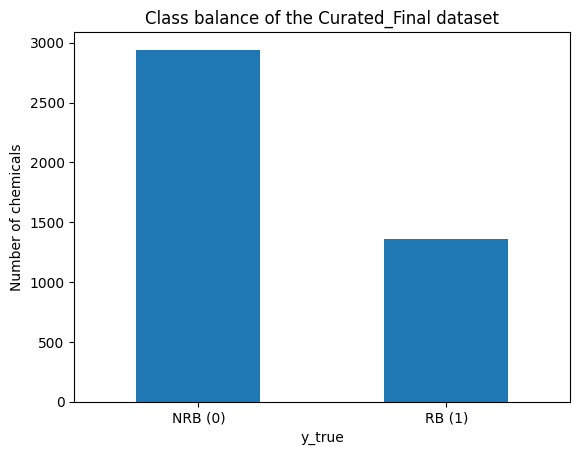

In [4]:
# value_counts() counts how many times each unique value appears in a column.
# normalize=True turns the counts into fractions (so they sum to 1.0 / 100%).
class_counts = df["y_true"].value_counts()
class_fractions = df["y_true"].value_counts(normalize=True)

print("Class counts:")
print(class_counts)
print()
print("Class fractions:")
print((class_fractions * 100).round(1).astype(str) + " %")

# A quick bar chart of the two classes.
class_counts.rename({0: "NRB (0)", 1: "RB (1)"}).plot(kind="bar", rot=0)
plt.ylabel("Number of chemicals")
plt.title("Class balance of the Curated_Final dataset")
plt.show()


## 2. Turning molecules into numbers: feature engineering

scikit-learn models only understand numbers - specifically, each observation ("row")
must be represented as a fixed-length vector of numbers, called a **feature vector**. A
SMILES string like `OCC1=CC=CC=C1` is not a number, so we first have to convert it.

The paper tested seven different ways of doing this ("fingerprints", see Section 3.4.2)
and found that **MACCS keys** combined with XGBoost gave the best results (balanced
accuracy 84.9%, later 94.2% after label-noise filtering - see Table 1). We use the same
representation here because it is simple to explain: a MACCS fingerprint is a vector of
**167 zeros and ones**, where each position answers one yes/no question about the
molecule's structure, such as "does it contain a ring?" or "does it contain a halogen
atom?". Two molecules that "look similar" chemically will tend to have similar
fingerprints, which is exactly the property a classifier needs to be able to learn from.

The steps below are:
1. Convert each SMILES string into an RDKit "molecule" object (`Chem.MolFromSmiles`).
2. Compute its 167-bit MACCS fingerprint (`MACCSkeys.GenMACCSKeys`).
3. Turn the fingerprint into a numpy array so it can be stacked into a big feature matrix
   `X` (this is standard scikit-learn notation: `X` = features/inputs, `y` = labels/targets).


In [ ]:
def smiles_to_maccs(smiles: str):
    # Convert one SMILES string into a 167-bit MACCS fingerprint (as a numpy array).
    # Returns None if RDKit cannot parse the SMILES (this occasionally happens with
    # unusual or malformed structures) so that we can filter those rows out afterwards.
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fingerprint = MACCSkeys.GenMACCSKeys(mol)   # RDKit's own bit-vector type
    return np.array(fingerprint)                # convert to a plain numpy array of 0/1

# .apply() runs our function once for every row of the "smiles" column - this is the
# pandas equivalent of a for-loop, but faster and more idiomatic.
fingerprints = df["smiles"].apply(smiles_to_maccs)

# Some SMILES might have failed to parse (fingerprints entry is None in that case).
# .notna() gives us a boolean mask (True/False for every row) that we can use to keep
# only the valid ones - both for the features and for the matching labels.
valid_mask = fingerprints.notna()
n_dropped = (~valid_mask).sum()
print(f"{n_dropped} out of {len(df)} SMILES could not be parsed by RDKit and were dropped.")

# np.vstack stacks a list/Series of 1-D arrays (one per molecule) into a single 2-D
# array: shape (n_molecules, 167). This 2-D array is exactly the "X" that scikit-learn
# expects: one row per sample, one column per feature.
X = np.vstack(fingerprints[valid_mask].values)
y = df.loc[valid_mask, "y_true"].values

print(f"Feature matrix X: {X.shape[0]} molecules x {X.shape[1]} MACCS bits")
print(f"Label vector y:   {y.shape[0]} labels")


0 out of 4298 SMILES could not be parsed by RDKit and were dropped.
Feature matrix X: 4298 molecules x 167 MACCS bits
Label vector y:   4298 labels


### 2.1 Sanity-checking the features

It's good practice to actually *look* at a feature vector at least once, so it stops
being an abstract black box. Below we print the fingerprint of the first molecule in the
dataset, and show how many of the 167 bits are "on" (=1) on average.


In [ ]:
print("SMILES of the first molecule:", df.loc[df.index[valid_mask][0], "smiles"])
print("Its 167-bit MACCS fingerprint:")
print(X[0])
print()
print(f"On average, {X.mean(axis=1).mean() * 167:.1f} out of 167 bits are set to 1 per molecule.")


SMILES of the first molecule: OCC1=CC=CC=C1
Its 166-bit MACCS fingerprint:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0]

On average, 28.1 out of 166 bits are set to 1 per molecule.


## 3. A quick look with a single train/test split

The most basic way to evaluate a model is to split the data once into a **training set**
(used to fit/teach the model) and a **test set** (used only to check performance, on data
the model has never seen). This is a good way to *build intuition* before moving to the
more robust cross-validation approach in Section 4.

Two important details, both directly inspired by the paper's methodology
(Section 3.5, "Model testing"):

- `stratify=y` makes sure that both the training set and the test set keep the same
  proportion of RB/NRB chemicals as the full dataset. Without this, a random split could
  accidentally put too many/few examples of one class into the test set, especially for
  an imbalanced dataset like this one (about 32% RB vs. 68% NRB).
- We fit the model **only** on the training data. It is extremely important to never let
  the model see the test set during training - otherwise you are not testing whether it
  generalises to new chemicals, just whether it can memorise the ones it has already seen.


In [7]:
# train_test_split shuffles the data and splits it into two parts.
# test_size=0.2 means 20% of the data is held out for testing, 80% is used for training
# (the paper uses this same 80/20 ratio, see Section 3.5).
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,                 # keep the same RB/NRB ratio in both splits
    random_state=RANDOM_STATE,  # reproducibility
)

print(f"Training set: {X_train.shape[0]} molecules")
print(f"Test set:     {X_test.shape[0]} molecules")

# Let's fit one single, simple model first, just to see the whole pipeline end to end
# before we start comparing several models in Section 4.
baseline_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

# .fit(X, y) is the standard scikit-learn call for "learn from this data".
baseline_model.fit(X_train, y_train)

# .predict(X) asks the already-fitted model to guess the label for new, unseen data.
y_pred = baseline_model.predict(X_test)

# balanced_accuracy_score is the average of the recall (sensitivity) obtained on each
# class. It treats the minority and majority classes as equally important, which is
# exactly why the paper (and we) use it instead of plain accuracy for this imbalanced
# dataset (definition given in ESI-1 Section S1.8 of the paper).
bal_acc = balanced_accuracy_score(y_test, y_pred)
print(f"\nBalanced accuracy on the held-out test set: {bal_acc:.3f}")


Training set: 3438 molecules
Test set:     860 molecules



Balanced accuracy on the held-out test set: 0.940


### 3.1 Looking beyond a single number: the confusion matrix

A single accuracy number hides *how* a model gets things wrong. A **confusion matrix**
shows, for every true class, how many chemicals were predicted correctly and how many
were confused with the other class. This directly corresponds to the "sensitivity" and
"specificity" columns reported throughout Tables 1 and 2 of the paper:

- **Sensitivity** (a.k.a. recall for the positive/RB class) = of all truly RB chemicals,
  what fraction did the model correctly flag as RB?
- **Specificity** = of all truly NRB chemicals, what fraction did the model correctly
  flag as NRB?


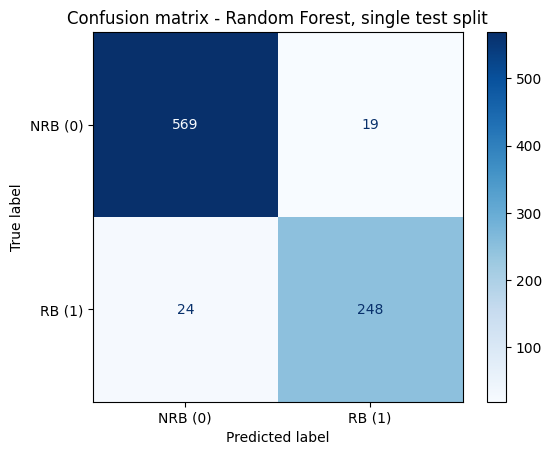

              precision    recall  f1-score   support

     NRB (0)       0.96      0.97      0.96       588
      RB (1)       0.93      0.91      0.92       272

    accuracy                           0.95       860
   macro avg       0.94      0.94      0.94       860
weighted avg       0.95      0.95      0.95       860



In [8]:
cm = confusion_matrix(y_test, y_pred)

# ConfusionMatrixDisplay draws the matrix as an easy-to-read image instead of a plain
# table of numbers.
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NRB (0)", "RB (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix - Random Forest, single test split")
plt.show()

# classification_report prints precision, recall (=sensitivity) and f1-score for each
# class in one readable block - a nice complement to the confusion matrix above.
print(classification_report(y_test, y_pred, target_names=["NRB (0)", "RB (1)"]))


## 4. Comparing several models fairly with cross-validation

A single train/test split has a weakness: the reported score depends a bit on *which*
molecules happened to land in the test set (bad luck with an easy or hard subset can
shift the number by a percentage point or two). The paper deals with this by repeating
the split several times (**5-fold cross-validation**, Section 3.5). We do the same here.

**How k-fold cross-validation works:**
1. The dataset is split into *k* equally-sized parts ("folds") - we use *k* = 5.
2. The model is trained *k* times. Each time, one fold is held out as the test set and
   the other *k*-1 folds are used for training.
3. This gives *k* separate performance scores, which we then average. The standard
   deviation across the *k* scores tells us how *stable* the estimate is.

We again use `StratifiedKFold`, for the same class-imbalance reason as in Section 3.

### 4.1 Defining the models to compare, as a list of `(name, classifier)` tuples

Instead of hard-coding one single model, we define a **list of tuples**: each tuple pairs
a human-readable name with a scikit-learn classifier object. This has a very practical
advantage: if you want to skip a slow or uninteresting model, you can just comment out
its line with a `#` - no other code needs to change, because the loop in the next cell
simply iterates over whatever is left in the list.


In [9]:
# Each tuple is (display_name, scikit-learn_estimator_instance).
# Feel free to comment/uncomment lines to change which models get evaluated below.
models = [
    ("Dummy (baseline)",     DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)),
    ("Logistic Regression",  LogisticRegression(max_iter=2000)),
    ("K-Nearest Neighbors",  KNeighborsClassifier(n_neighbors=3)),
    # ("Linear SVM",          SVC(kernel="linear", C=0.025, random_state=RANDOM_STATE)),
    # ("RBF SVM",             SVC(random_state=RANDOM_STATE)),
    # ("Decision Tree",       DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ("Random Forest",        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)),
    ("Gradient Boosting",    GradientBoostingClassifier(random_state=RANDOM_STATE)),
]

# Why a "Dummy" classifier? It ignores the features completely and just predicts
# labels according to the class frequencies it saw during training. It is a sanity
# floor: any model worth using must clearly beat the dummy, otherwise it has not
# actually learned anything useful from the chemical structures.
for name, _ in models:
    print("-", name)


- Dummy (baseline)
- Logistic Regression
- K-Nearest Neighbors
- Random Forest
- Gradient Boosting


In [10]:
# StratifiedKFold: like a regular K-fold split, but keeps the class proportions
# (RB vs NRB) approximately constant in every fold - important for imbalanced data.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = {}  # will hold, for each model name, the array of 5 balanced-accuracy scores

for name, clf in models:
    print(f"Running 5-fold cross-validation for: {name} ...")

    # cross_val_score takes care of the whole "split -> train -> predict -> score"
    # loop for us, k times, and simply returns the k resulting scores.
    # scoring="balanced_accuracy" tells scikit-learn to compute the same metric the
    # paper uses, instead of plain accuracy.
    scores = cross_val_score(
        clf, X, y,
        cv=cv,
        scoring="balanced_accuracy",
        n_jobs=-1,  # use all available CPU cores to run the folds in parallel (faster)
    )
    results[name] = scores
    print(f"    balanced accuracy: {scores.mean():.3f} +/- {scores.std():.3f}\n")


Running 5-fold cross-validation for: Dummy (baseline) ...
    balanced accuracy: 0.492 +/- 0.013

Running 5-fold cross-validation for: Logistic Regression ...


    balanced accuracy: 0.910 +/- 0.008

Running 5-fold cross-validation for: K-Nearest Neighbors ...


    balanced accuracy: 0.906 +/- 0.007

Running 5-fold cross-validation for: Random Forest ...


    balanced accuracy: 0.933 +/- 0.011

Running 5-fold cross-validation for: Gradient Boosting ...


    balanced accuracy: 0.913 +/- 0.015



### 4.2 Turning the results into a tidy table and a plot

Finally, we collect all cross-validation scores into a single dataframe (one row per
model, one column per fold) and visualise the average performance, similar in spirit to
Fig. 3 of the paper, which compares balanced accuracy across several dataset
versions/models with box plots.


In [11]:
# pd.DataFrame(dict) with a dict of {name: array_of_scores} automatically builds a
# table with one column per model and one row per cross-validation fold.
results_df = pd.DataFrame(results)
print("Balanced accuracy for every fold:")
display(results_df.round(3))

print("\nSummary (mean +/- standard deviation), sorted from best to worst:")
summary = results_df.agg(["mean", "std"]).T.sort_values("mean", ascending=False)
display(summary.round(3))


Balanced accuracy for every fold:


,Dummy (baseline),Logistic Regression,K-Nearest Neighbors,Random Forest,Gradient Boosting
0,0.504,0.917,0.903,0.937,0.910
1,0.488,0.921,0.918,0.950,0.938
2,0.469,0.910,0.899,0.927,0.917
3,0.504,0.900,0.907,0.929,0.907
4,0.496,0.901,0.901,0.919,0.893



Summary (mean +/- standard deviation), sorted from best to worst:


,mean,std
Random Forest,0.933,0.012
Gradient Boosting,0.913,0.016
Logistic Regression,0.910,0.009
K-Nearest Neighbors,0.906,0.008
Dummy (baseline),0.492,0.015


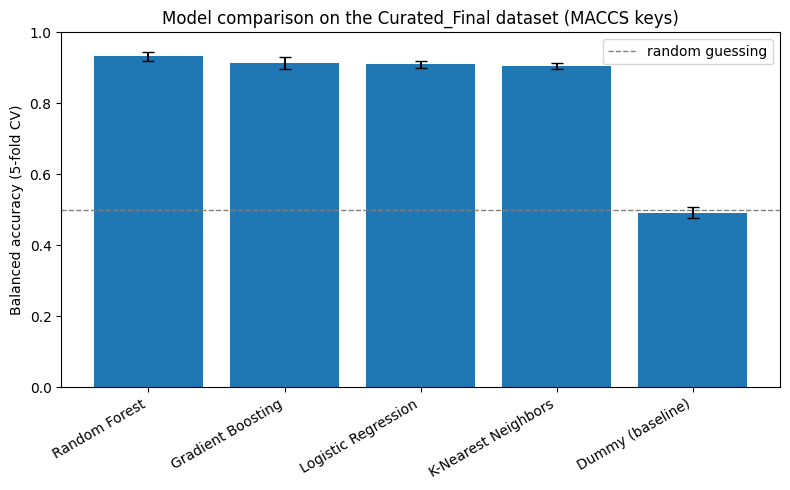

In [12]:
# A bar chart with error bars is a simple, readable way to compare models: the bar
# height is the mean balanced accuracy, the error bar (whisker) is the standard
# deviation across the 5 folds.
order = summary.index  # best-to-worst order, computed in the cell above

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    order,
    summary.loc[order, "mean"],
    yerr=summary.loc[order, "std"],
    capsize=4,
)
ax.set_ylabel("Balanced accuracy (5-fold CV)")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=1, label="random guessing")
ax.set_title("Model comparison on the Curated_Final dataset (MACCS keys)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Recap and where to go from here

You have now walked through a complete, minimal ML pipeline:

1. **Load** a real chemical dataset with `pandas`.
2. **Engineer features**: turn each molecule's SMILES string into a numeric MACCS
   fingerprint with RDKit, because scikit-learn cannot work with raw text/structures.
3. **Split the data** correctly (stratified, so class balance is preserved).
4. **Fit and evaluate** a first model, inspecting more than a single accuracy number
   (confusion matrix, per-class metrics).
5. **Compare several models fairly** using stratified 5-fold cross-validation and an
   imbalance-aware metric (balanced accuracy), organised as an easily editable list of
   `(name, classifier)` tuples.

A few directions for going further, all inspired directly by the paper:

- **Try other fingerprints.** The paper tested Avalon, ECFP, RDKit and other
  fingerprints in addition to MACCS keys (Section 3.4.2 / 4.4.3) - RDKit can compute
  several of these too (e.g. `Chem.rdMolDescriptors.GetHashedMorganFingerprint`).
- **Try hyperparameter tuning.** We used every model's default settings. The paper used
  Bayesian optimisation (Section 3.7) on top of model selection; a beginner-friendly
  first step would be `sklearn.model_selection.GridSearchCV` or `RandomizedSearchCV`.
- **Investigate label noise.** The paper's central finding is that a large share of the
  original difficulty came from unreliable experimental labels, not from the model or
  the features (Section 4.3-4.4). Cleaning the *labels* mattered far more than switching
  models or fingerprints - a valuable and often underrated lesson for any ML project.
- **Look at feature importance.** The paper uses SHAP values (Section 4.6, Fig. 5) to
  show that halogens and aromatic rings bound to nitrogen make a molecule harder to
  biodegrade, while carboxyl/hydroxyl groups make it easier. A simpler beginner-friendly
  starting point is `RandomForestClassifier(...).feature_importances_`.
